# Data Fetcher Playground
Sandbox for experimenting with `get_stock_data` from `backend/00_data/data_fetcher.py`.

In [1]:
import sys
import os

# Makes data_fetcher importable when Jupyter is launched from the project root.
# If you launched Jupyter from inside backend/00_data/, change to '.' instead.
sys.path.insert(0, 'backend/00_data')

from data_fetcher import get_stock_data

## Basic usage — daily bars (default)

In [2]:
df = get_stock_data('SNDK')
print(f'{len(df)} rows, columns: {list(df.columns)}')
df.tail(5)

60 rows, columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-11 04:00:00,1586.250000,1600.000000,1514.469971,1547.560059,16516800,0.0,0.0
2026-05-12 04:00:00,1492.000000,1508.319946,1367.000000,1452.020020,17138500,0.0,0.0
2026-05-13 04:00:00,1512.484985,1513.569946,1404.859985,1447.229980,11618700,0.0,0.0
2026-05-14 04:00:00,1394.400024,1453.770020,1362.000000,1382.719971,11213600,0.0,0.0
2026-05-15 04:00:00,1321.000000,1426.378052,1315.750000,1407.609985,13937400,0.0,0.0


## Plot OHLC candlesticks (playground only)

Helper below is for visual checks only — not part of `data_fetcher.py` or the bot pipeline. Requires `mplfinance` (`pip install mplfinance`).

In [6]:
import mplfinance as mpf


def plot_stock_df(df, ticker: str = '') -> None:
    """Plot OHLC candlesticks from a yfinance DataFrame. Playground use only."""
    if df is None or df.empty:
        print('[plot] no data to plot')
        return

    required = ['Open', 'High', 'Low', 'Close']
    if not all(col in df.columns for col in required):
        print(f'[plot] missing columns — need {required}')
        return

    plot_df = df[required].copy()
    if 'Volume' in df.columns:
        plot_df['Volume'] = df['Volume']

    title = f'{ticker} — OHLC' if ticker else 'OHLC'
    mpf.plot(
        plot_df,
        type='candle',
        style='charles',
        title=title,
        volume='Volume' in plot_df.columns,
        figsize=(10, 5),
    )

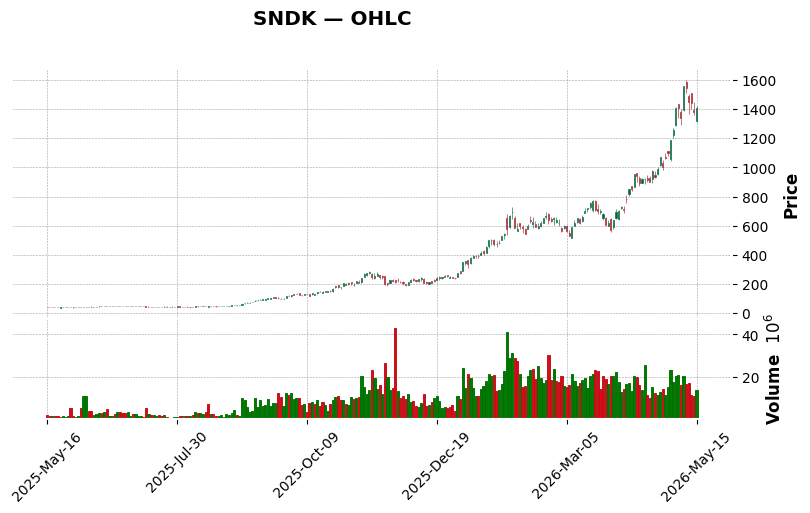

In [10]:
df = get_stock_data('SNDK', period='1y', interval='1d')
plot_stock_df(df, 'SNDK')

## Change the period

In [3]:
# Valid period values: '1d','5d','1mo','3mo','6mo','1y','2y','5y','max'
df_1y = get_stock_data('AAPL', period='1y')
print(f'1 year of data: {len(df_1y)} rows')
df_1y.head(3)

1 year of data: 251 rows


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-05-16 04:00:00,211.520861,211.730038,208.941099,210.425201,54737900,0.0,0.0
2025-05-19 04:00:00,207.088445,208.652233,203.452858,207.955002,46140500,0.0,0.0
2025-05-20 04:00:00,206.849384,207.646226,204.219817,206.042587,42496600,0.0,0.0


## Change the interval

In [4]:
# Valid interval values: '1m','5m','15m','30m','1h','1d','1wk','1mo'
# Note: intraday intervals only go back 60 days max
df_hourly = get_stock_data('AAPL', period='5d', interval='1h')
print(f'5 days of hourly bars: {len(df_hourly)} rows')
df_hourly.tail(5)

5 days of hourly bars: 35 rows


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-05-15 15:30:00,301.989990,302.600006,300.640015,301.809998,4948994,0.0,0.0
2026-05-15 16:30:00,301.790009,303.200012,301.484985,303.119995,4106966,0.0,0.0
2026-05-15 17:30:00,302.970001,303.140015,301.118011,301.265015,4178682,0.0,0.0
2026-05-15 18:30:00,301.279999,301.760010,299.880005,300.263397,4233250,0.0,0.0
2026-05-15 19:30:00,300.279999,300.660004,299.630005,300.220001,4618896,0.0,0.0


## Test error handling — bad ticker

In [5]:
result = get_stock_data('FAKEXYZ')
print(result)  # should print a warning and return None

[data] FAKEXYZ: fetch failed — HTTP Error 404: 
None


## Try your own ticker

---

## News Headlines — `get_news_headlines()`
Sandbox for experimenting with `get_news_headlines` from `backend/00_data/data_fetcher.py`.

In [2]:
from data_fetcher import get_news_headlines

### Happy path

In [4]:
headlines = get_news_headlines('AAPL')
print(f'Fetched {len(headlines)} headlines')
# Show first result with all fields
headlines[10]

Fetched 20 headlines


{'headline': 'S&P 500 and Nasdaq 100 Post New Record Highs on Chip Stock Strength',
 'description': 'The S&P 500 Index ($SPX ) (SPY ) on Wednesday closed up +0.58%, the Dow Jones Industrial Average ($DOWI ) (DIA ) closed down -0.14%, and the Nasdaq 100 Index...',
 'source': 'Barchart.com',
 'url': 'https://www.barchart.com/story/news/1914958/s-p-500-and-nasdaq-100-post-new-record-highs-on-chip-stock-strength',
 'published_at': '2026-05-13T20:37:40Z'}

### Variations — different tickers & lookback windows

In [5]:
# More articles with max_results
more = get_news_headlines('NVDA', days_back=3, max_results=5)
print(f'NVDA (3 days, 5 articles): {len(more) if more else 0} headlines')

# Longer lookback
long_ = get_news_headlines('TSLA', days_back=14, max_results=50)
print(f'TSLA (14 days, 50 articles): {len(long_) if long_ else 0} headlines')

NVDA (3 days, 5 articles): 5 headlines
TSLA (14 days, 50 articles): 45 headlines


### Test error handling — missing API key

In [8]:
import os

# Simulate a missing key — temporarily blank it out
saved_key = os.environ.get('NEWS_API_KEY')
os.environ['NEWS_API_KEY'] = ''
result = get_news_headlines('AAPL')
print(result)  # should print a warning and return None

# Restore
if saved_key:
    os.environ['NEWS_API_KEY'] = saved_key

[data] AAPL: no NEWS_API_KEY found in environment
None


In [9]:
# Try any ticker or query string
get_news_headlines('AAPL', days_back=5, max_results=5)


[{'headline': 'lumilake added to PyPI',
  'description': 'Data analytics engine for agentic workflows',
  'source': 'Pypi.org',
  'url': 'https://pypi.org/project/lumilake/',
  'published_at': '2026-05-15T08:09:37Z'},
 {'headline': "Apple's 2026 Outlook: Strong Earnings and AI Initiatives Drive Growth",
  'description': "Apple's 2026 outlook remains positive with strong earnings growth, AI initiatives, and high iPhone demand. Analysts maintain a Moderate Buy consensus, highlighting potential upside despite some risks.",
  'source': 'Ibtimes.com.au',
  'url': 'https://www.ibtimes.com.au/apple-2026-outlook-earnings-ai-growth-1868869',
  'published_at': '2026-05-15T08:08:20Z'},
 {'headline': 'finresearch-cli added to PyPI',
  'description': 'Finance CLI for public-company research, filings, documents, market data, valuation helpers, and backtests.',
  'source': 'Pypi.org',
  'url': 'https://pypi.org/project/finresearch-cli/',
  'published_at': '2026-05-15T01:10:55Z'},
 {'headline': 'Apple